In [1]:
import sys
sys.executable

'/home/nicolofiaba/Desktop/jupyter-notebooks/Projects/proj3-pytorch-classifier/.venv/bin/python'

# PyTorch Classifier - Wine Quality Detection

In [2]:
import numpy as np
import torch
from torchvision.transforms import v2
import kagglehub
from pathlib import Path
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
class WineDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X = self.data[idx]
        y = self.labels[idx] - 3

        return X, y

# Neural Network Approach (PyTorch)

## Dataset and Dataloader preparation

In [4]:
data = pd.read_csv("data/winequality-red.csv")
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

In [8]:
wd_train = WineDataset(X_train_sc, y_train)
wd_test = WineDataset(X_test_sc, y_test)

In [9]:
train_dataloader = DataLoader(wd_train, batch_size=64, shuffle=True)
test_dataloader = DataLoader(wd_test, batch_size=64, shuffle=False)

## Model definition and Training

In [10]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [11]:
from torch import nn

In [12]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(11, 33),
            nn.ReLU(),
            nn.Linear(33, 33),
            nn.ReLU(),
            nn.Linear(33, 6)
        )

    def forward(self, x):
        return self.linear_relu_stack(x)

In [13]:
model = NeuralNetwork().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
from sklearn.metrics import confusion_matrix

In [15]:
epochs = 20

for epoch in range(epochs):

    # Start the training process
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for X, y in train_dataloader: 
    
        pred = model(X)
        loss = loss_fn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predicted = pred.argmax(dim=1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)
        
    train_loss /= len(train_dataloader)
    train_accuracy = train_correct / train_total

    # Validation
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X, y in test_dataloader:
            pred = model(X)
            loss = loss_fn(pred, y)

            val_loss += loss.item()

            predicted = pred.argmax(dim=1)
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss /= len(test_dataloader)
    val_accuracy = val_correct / val_total

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"| Train loss: {train_loss:.4f} "
        f"| Train acc: {train_accuracy:.3f} "
        f"| Val loss: {val_loss:.4f} "
        f"| Val acc: {val_accuracy:.3f}"
    )

Epoch 1/20 | Train loss: 1.6893 | Train acc: 0.336 | Val loss: 1.6044 | Val acc: 0.478
Epoch 2/20 | Train loss: 1.5285 | Train acc: 0.474 | Val loss: 1.4196 | Val acc: 0.503
Epoch 3/20 | Train loss: 1.3395 | Train acc: 0.500 | Val loss: 1.2231 | Val acc: 0.525
Epoch 4/20 | Train loss: 1.1932 | Train acc: 0.532 | Val loss: 1.1068 | Val acc: 0.559
Epoch 5/20 | Train loss: 1.1086 | Train acc: 0.559 | Val loss: 1.0457 | Val acc: 0.584
Epoch 6/20 | Train loss: 1.0568 | Train acc: 0.575 | Val loss: 1.0111 | Val acc: 0.572
Epoch 7/20 | Train loss: 1.0207 | Train acc: 0.582 | Val loss: 0.9952 | Val acc: 0.575
Epoch 8/20 | Train loss: 0.9957 | Train acc: 0.587 | Val loss: 0.9846 | Val acc: 0.575
Epoch 9/20 | Train loss: 0.9785 | Train acc: 0.592 | Val loss: 0.9815 | Val acc: 0.578
Epoch 10/20 | Train loss: 0.9652 | Train acc: 0.600 | Val loss: 0.9797 | Val acc: 0.584
Epoch 11/20 | Train loss: 0.9526 | Train acc: 0.601 | Val loss: 0.9765 | Val acc: 0.606
Epoch 12/20 | Train loss: 0.9439 | Train 

In [16]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X, y in test_dataloader:
        pred = model(X)

        y_true.extend(y.numpy())
        y_pred.extend(pred.argmax(dim=1).numpy())

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[  0   0   1   0   0   0]
 [  0   0   4   4   0   0]
 [  0   0 100  38   2   0]
 [  0   0  47  80   6   0]
 [  0   0   6  15  15   0]
 [  0   0   0   1   1   0]]


### Check the balance of the dataset

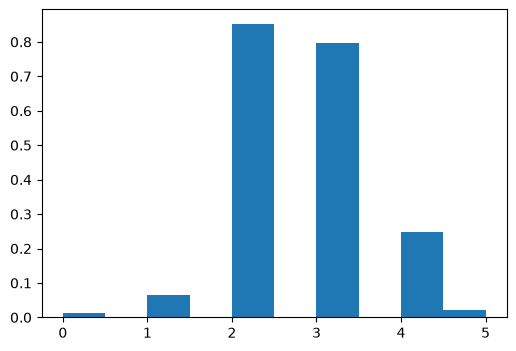

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(data.iloc[:, -1]-3, density=True)
plt.show()

In [25]:
data_2 = data.copy()

data_2.loc[data_2['quality'].isin([3, 4]), 'quali_class'] = 0
data_2.loc[data_2['quality'].isin([5, 6]), 'quali_class'] = 1
data_2.loc[data_2['quality'].isin([7, 8]), 'quali_class'] = 2

In [ ]:
data_2 = data_2.drop(columns="quality")

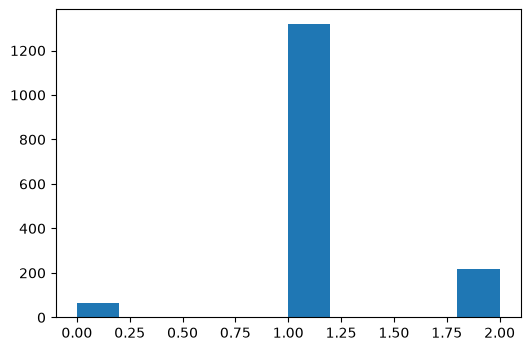

In [33]:
plt.figure(figsize=(6,4))
plt.hist(data_2.iloc[:, -1])
plt.show()